In [1]:
from collections.abc import Sequence
from sklearn import preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shutil
import os


# Encode text values to dummy variables(i.e. [1,0,0],[0,1,0],[0,0,1] for red,green,blue)
def encode_text_dummy(df, name):
    dummies = pd.get_dummies(df[name])
    for x in dummies.columns:
        dummy_name = "{}-{}".format(name, x)
        df[dummy_name] = dummies[x]
    df.drop(name, axis=1, inplace=True)



# Encode text values to indexes(i.e. [1],[2],[3] for red,green,blue).
def encode_text_index(df, name):
    le = preprocessing.LabelEncoder()
    df[name] = le.fit_transform(df[name])
    return le.classes_


# Encode a numeric column as zscores
def encode_numeric_zscore(df, name, mean=None, sd=None):
    if mean is None:
        mean = df[name].mean()

    if sd is None:
        sd = df[name].std()

    df[name] = (df[name] - mean) / sd


# Convert all missing values in the specified column to the median
def missing_median(df, name):
    med = df[name].median()
    df[name] = df[name].fillna(med)


# Convert all missing values in the specified column to the default
def missing_default(df, name, default_value):
    df[name] = df[name].fillna(default_value)


# Convert a Pandas dataframe to the x,y inputs that TensorFlow needs
def to_xy(df, target):
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    # find out the type of the target column. 
    target_type = df[target].dtypes
    target_type = target_type[0] if isinstance(target_type, Sequence) else target_type
    # Encode to int for classification, float otherwise. TensorFlow likes 32 bits.
    if target_type in (np.int64, np.int32):
        # Classification
        dummies = pd.get_dummies(df[target])
        return df[result].values.astype(np.float32), dummies.values.astype(np.float32)
    else:
        # Regression
        return df[result].values.astype(np.float32), df[target].values.astype(np.float32)

# Nicely formatted time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return "{}:{:>02}:{:>05.2f}".format(h, m, s)


# Regression chart.
def chart_regression(pred,y,sort=True):
    t = pd.DataFrame({'pred' : pred, 'y' : y.flatten()})
    if sort:
        t.sort_values(by=['y'],inplace=True)
    a = plt.plot(t['pred'].tolist(),label='prediction')
    b = plt.plot(t['y'].tolist(),label='expected')
    plt.ylabel('output')
    plt.legend()
    plt.show()

# Remove all rows where the specified column is +/- sd standard deviations
def remove_outliers(df, name, sd):
    drop_rows = df.index[(np.abs(df[name] - df[name].mean()) >= (sd * df[name].std()))]
    df.drop(drop_rows, axis=0, inplace=True)


# Encode a column to a range between normalized_low and normalized_high.
def encode_numeric_range(df, name, normalized_low=-1, normalized_high=1,
                         data_low=None, data_high=None):
    if data_low is None:
        data_low = min(df[name])
        data_high = max(df[name])

    df[name] = ((df[name] - data_low) / (data_high - data_low)) \
               * (normalized_high - normalized_low) + normalized_low

In [2]:
# ignores terms that appear in more than max_df documents
MAX_DF = 0.90    
# Ignore terms that appear in fewer than min_df documents
MIN_DF = 0.05
# size of vocabulary
MAX_FEATURES = 50000
LEARNING_RATE=0.0001
BATCH_SIZE=32
EPOCHS=500
FILE_PATH = 'dataset/cleaned_dataset/training_dataset.json'

In [3]:
import tensorflow as tf

with tf.device('/GPU:0'):
    df = pd.read_json(FILE_PATH, lines=True)
    print(f'Shape: {df.shape}')
    print(f'Columns: {df.columns}')

2026-06-09 12:11:10.961959: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-09 12:11:10.962010: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-09 12:11:10.962014: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-09 12:11:10.962057: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-09 12:11:10.962075: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Shape: (61919, 6)
Columns: Index(['business_id', 'state', 'business_star', 'review_count',
       'average_review_ratings_df', 'text'],
      dtype='object')


In [4]:
df.head()

,business_id,state,business_star,review_count,average_review_ratings_df,text
0,tUFrWirKiKi_TAnsVWINQQ,AZ,3.5,22,3.500000,We are fans of Target. They seem to have a li...
1,MTSW4McQd7CbVtyjqoe9mw,PA,4.0,80,4.057471,This is nice little Chinese bakery in the hear...
2,il_Ro8jwPlHresjw9EGmBg,IN,2.5,28,2.413793,Went there at 4am and there was only one waitr...
3,0bPLkL0QhhPO5kt1_EXmNQ,FL,4.5,100,4.386792,The worst Chicken Parm. Sandwich I've ever eat...
4,MUTTqe8uqyMdBl186RmNeA,PA,4.0,245,4.200000,Stopped in to check out this new spot around t...


In [5]:
import sklearn.feature_extraction.text as sk_text
from sklearn.model_selection import train_test_split

with tf.device('/GPU:0'):
    encode_text_dummy(df, 'state')
    encode_numeric_zscore(df, 'review_count')
    encode_numeric_zscore(df, 'average_review_ratings_df')

    df = df.set_index('business_id', drop=True)

    vectorizer = sk_text.TfidfVectorizer(
        stop_words='english',
        max_features=MAX_FEATURES,
        max_df=MAX_DF,
        min_df=MIN_DF,
        ngram_range=(1,2)
    )

    text_matrix = vectorizer.fit_transform(df['text'])

    text_dense_matrix = text_matrix.astype(np.float32).toarray()
    tfidf_df = pd.DataFrame(
        text_dense_matrix, 
        index=df.index, 
        columns=vectorizer.get_feature_names_out())
    full_df = pd.concat([df.drop(columns=['text']), tfidf_df], axis=1)

    ids = full_df.index.to_series(name='business_id')

    x,y = to_xy(full_df, target='business_star')
    x_train, x_test, y_train, y_test, id_train, id_test = train_test_split(x, y, ids, test_size=.20, random_state=42)


In [6]:
print(f'x shape: {x.shape}')
print(f'x shape: {y.shape}')

print(f'x test shape: {x_test.shape}')
print(f'y test shape: {y_test.shape}')

print(f'x train shape: {x_train.shape}')
print(f'y train shape: {y_train.shape}')

x shape: (61919, 8664)
x shape: (61919,)
x test shape: (12384, 8664)
y test shape: (12384,)
x train shape: (49535, 8664)
y train shape: (49535,)


/Users/phatdoan/CSC180-Intelligent-Systems/CSC180-Intelligent-Systems/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/phatdoan/CSC180-Intelligent-Systems/CSC180-Intelligent-Systems/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/3


2026-06-09 12:35:00.046009: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1548/1548 - 44s - 29ms/step - loss: 12941056.0000 - val_loss: 2687474.5000
Epoch 2/3
1548/1548 - 42s - 27ms/step - loss: 7864128512.0000 - val_loss: 14733586.0000
Epoch 3/3
1548/1548 - 42s - 27ms/step - loss: 6533444608.0000 - val_loss: 6610319.0000
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Score (RMSE): 2571.053772288709


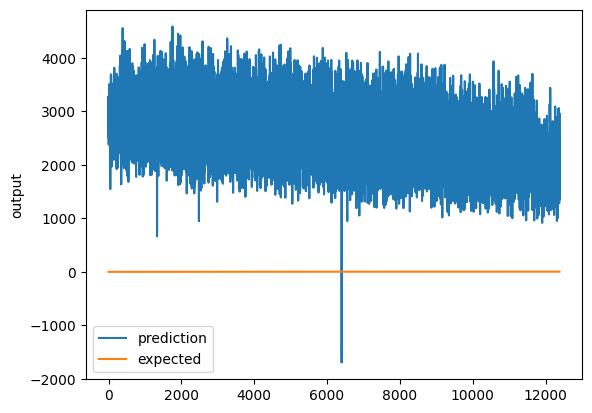

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import optimizers

from sklearn import metrics

model = Sequential()
model.add(Dense(2048, input_dim=x_train.shape[1], activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

adam = optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=0.9, beta_2=0.999, decay=0.0, amsgrad=False)
RMSProp = optimizers.RMSprop(learning_rate=LEARNING_RATE)

model.compile(loss='mean_squared_error', optimizer=RMSProp)

monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5, verbose=1, mode='min')
checkpointer = ModelCheckpoint(filepath='dnn/model_7/best_weights.keras', verbose=0, save_best_only=True)

with tf.device('/GPU:0'):
    model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=BATCH_SIZE, callbacks=[monitor, checkpointer], verbose=2, epochs=3)

    pred = model.predict(x_test)
    score = np.sqrt(metrics.mean_squared_error(pred, y_test))
    print("Score (RMSE): {}".format(score))

    chart_regression(pred.flatten(), y_test)

387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Score (RMSE): 133.09582280024793


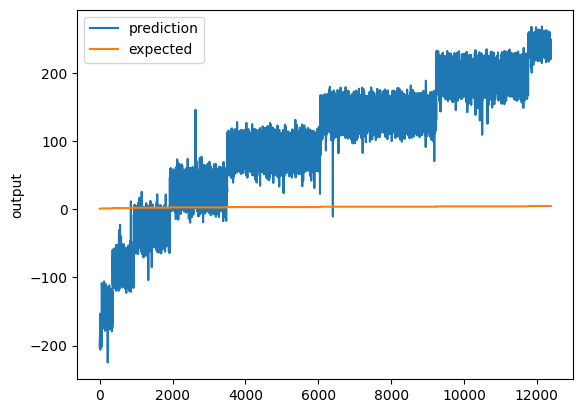

,business_id,actual_star,predicted_star,name
0,A1ONsZBHXJaI87_Cf7L8dA,3.5,101.449608,Supercuts
1,D7SxS4qCle_Nsv_ataoM1g,4.5,179.236359,Steadfast Commons
2,ZQc6EvnfQXtIK-8w-d0N5Q,3.5,85.174934,Mad Rex
3,SA_H07e5ec53hvxmjIK_nQ,5.0,230.919556,Dtown Tech
4,UmXR9Sj0PgYbLgtMjfk9UA,4.0,122.036942,Sea Lect Seafood


In [8]:
from tensorflow.keras.models import load_model
from sklearn import metrics

names = pd.read_json('dataset/cleaned_dataset/business_name.json', lines=True)

model = load_model('dnn/model_six/best_weights.keras')

pred = model.predict(x_test)
score = np.sqrt(metrics.mean_squared_error(pred, y_test))
print("Score (RMSE): {}".format(score))

chart_regression(pred.flatten(), y_test)

results = pd.DataFrame({
    'actual_star': y_test,
    'predicted_star': pred.flatten()
}, index=id_test)

results = results.merge(names, on='business_id', how='inner')
results.head()

In [9]:
model = load_model('dnn/model_six/best_weights.keras')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2048)           │    17,745,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,797,508 (159.44 MB)

 Trainable params: 20,898,753 (79.72 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,898,755 (79.72 MB)